In [1]:
"""
Created on Fri Mar 28 16:02:45 2025

@author: danielsaavedramorales
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.distributions.empirical_distribution import ECDF


# 1. Leer los datos y análisis descriptivo

In [2]:

# Asumo que los datos tienen columnas: Meses, Censura (1=evento, 0=censura)

data = pd.read_table("datos2_falla_Engine_Fan_Nelson_1982.txt", delim_whitespace=True)

# Porcentaje de censura
perc_censura = 1 - data['Censura'].mean()
print(f"Porcentaje de censura: {perc_censura:.2%}\n")

# Resumen estadístico
print("Resumen estadístico de Meses:")
print(data['Meses'].describe())
print(f"\nDesviación estándar: {data['Meses'].std():.2f}")
# =============================================================================
# 
# =============================================================================


Porcentaje de censura: 82.86%

Resumen estadístico de Meses:
count       70.000000
mean      4920.571429
std       2837.406902
min        450.000000
25%       2110.000000
50%       4300.000000
75%       7262.500000
max      11500.000000
Name: Meses, dtype: float64

Desviación estándar: 2837.41


# 2. Análisis gráfico inicial

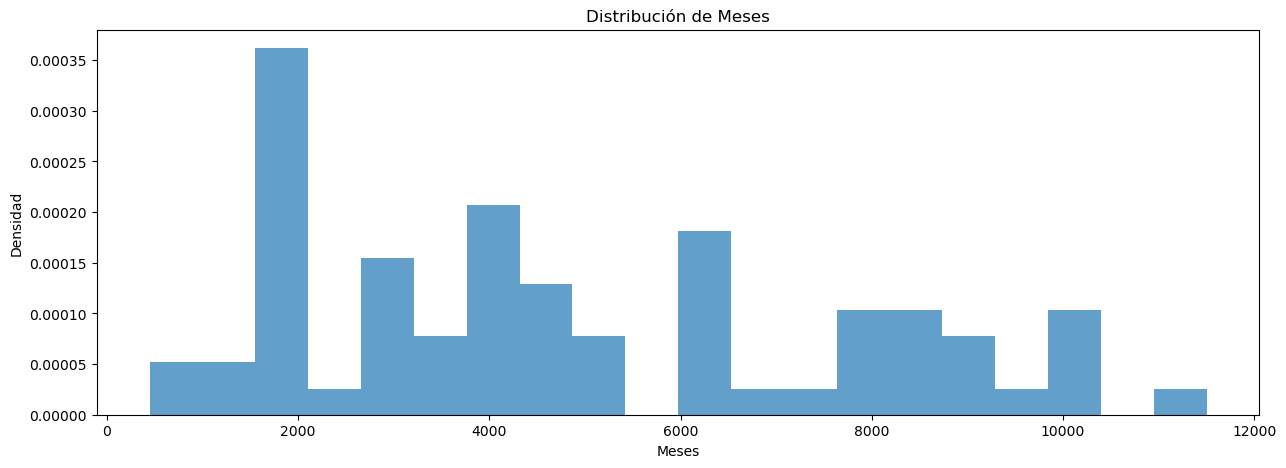

Text(0, 0.5, 'Probabilidad Acumulada')

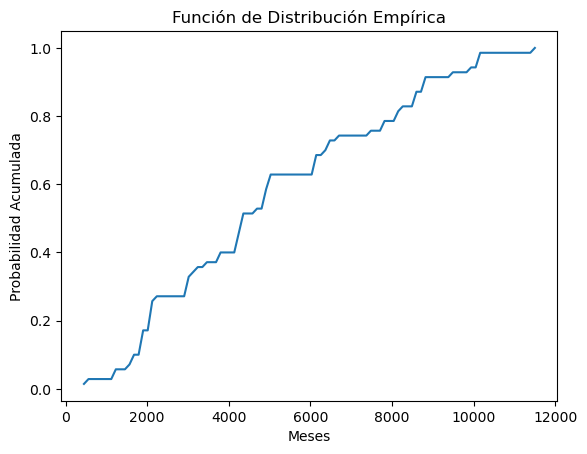

In [3]:

plt.figure(figsize=(15, 5))

# Histograma

plt.title('Distribución de Meses')
plt.xlabel('Meses')
plt.ylabel('Densidad')
plt.hist(data['Meses'], density=True,bins=20, alpha=0.7)
plt.show()

# Función de distribución empírica

empirical_cdf = ECDF(data['Meses'])
x = np.linspace(min(data['Meses']), max(data['Meses']), 100)
plt.plot(x, empirical_cdf(x))
plt.title('Función de Distribución Empírica')
plt.xlabel('Meses')
plt.ylabel('Probabilidad Acumulada')


# 3. Análisis de Kaplan-Meier

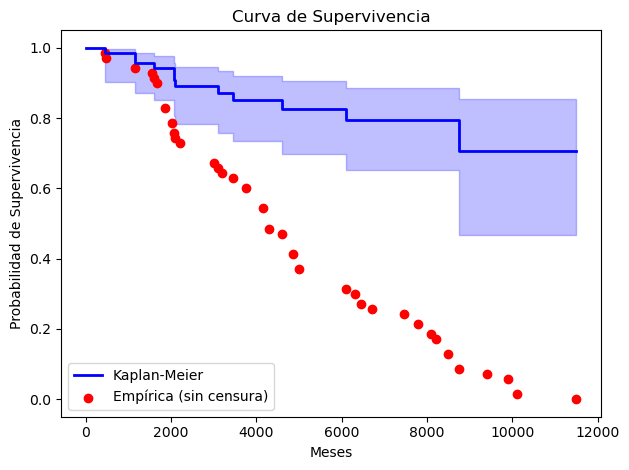


Estimación de Kaplan-Meier:
          Kaplan-Meier
timeline              
0.0           1.000000
450.0         0.985714
460.0         0.985714
1150.0        0.956723
1560.0        0.956723
1600.0        0.942004
1660.0        0.942004
1850.0        0.942004
2030.0        0.942004
2070.0        0.907749
2080.0        0.890622
2200.0        0.890622
3000.0        0.890622
3100.0        0.871672
3200.0        0.871672
3450.0        0.852302
3750.0        0.852302
4150.0        0.852302
4300.0        0.852302
4600.0        0.827234
4850.0        0.827234
5000.0        0.827234
6100.0        0.795418
6300.0        0.795418
6450.0        0.795418
6700.0        0.795418
7450.0        0.795418
7800.0        0.795418
8100.0        0.795418
8200.0        0.795418
8500.0        0.795418
8750.0        0.707038
9400.0        0.707038
9900.0        0.707038
10100.0       0.707038
11500.0       0.707038

Mediana de supervivencia: inf meses


In [4]:


kmf = KaplanMeierFitter()
kmf.fit(data['Meses'], event_observed=data['Censura'], label='Kaplan-Meier')
kmf.plot(color='blue', linewidth=2)

# Supervivencia empírica (sin censura)
times = np.sort(data['Meses'].unique())
surv_prob = 1 - empirical_cdf(times)
plt.scatter(times, surv_prob, color='red', label='Empírica (sin censura)')

plt.title('Curva de Supervivencia')
plt.xlabel('Meses')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 4. Resultados de Kaplan-Meier
print("\nEstimación de Kaplan-Meier:")
print(kmf.survival_function_)

# Mediana de supervivencia
median_survival = kmf.median_survival_time_
print(f"\nMediana de supervivencia: {median_survival:.2f} meses")
